In the name of God

# **Machine Learning Homework: Multilayer ANN from Scratch**

Seyed Mani Mirshabani 810801080

با توجه به اینکه قصد دارم در گیتهابم قرار بدم و بعدا به عنوان رزومه باشه با اجازه شما متن های نوتبوک رو به انگلیسی مینویسم (برای این کار از هوش مصنوعی استفاده نمیکنم و هرچیزی که متوجه شده باشم رو خودم به انگلیسی مینویسم برای همین پیشاپیش بابت اشتباهات مربوط به انگلیسی معذرت میخوام)

## **Part 1: Manual Forward and Backward Propagation**

Network architecture: 2 inputs → 2 hidden neurons (sigmoid) → 1 output neuron (sigmoid). Learning rate α = 0.1.

### Step 1: Given  

- Input vector: x = [1.0, 2.0]  
- Hidden layer weights: W1 = [[0.1, -0.2], [0.4, 0.2]]  
- Hidden layer biases: b1 = [0.0, 0.1]  
- Output layer weights: W2 = [0.3, -0.1]  
- Output layer bias: b2 = -0.1  
- Activation: σ(z) = 1/(1 + e^(−z))  
- Loss: L = 0.5·(ŷ − y)², with true label y = 1

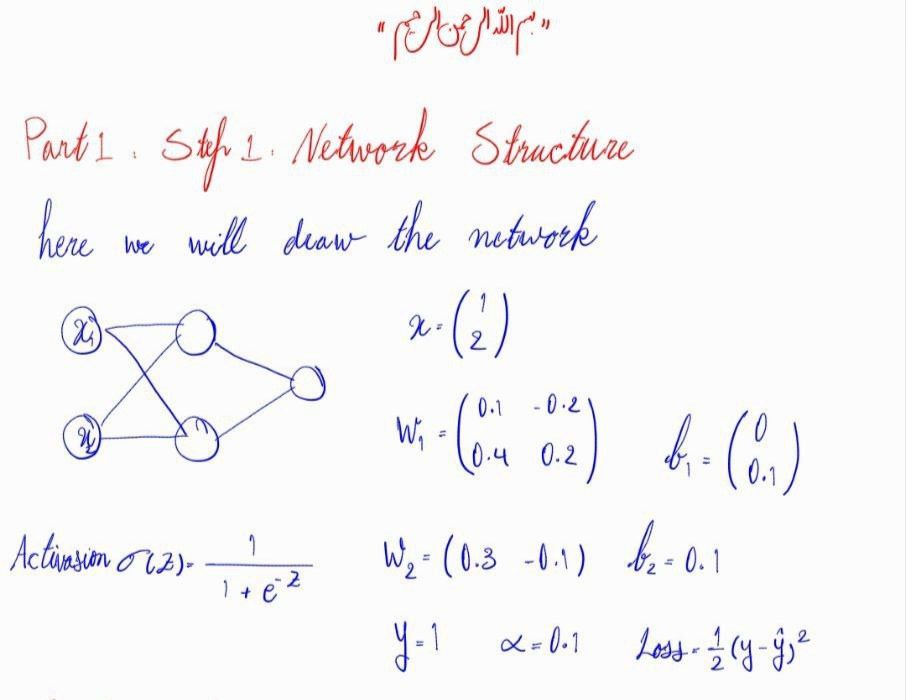

### Step 2: Forward Pass  


2.1 Compute hidden pre-activations z¹ = W1·x + b1  
2.2 Compute hidden activations a¹ = σ(z¹)  
2.3 Compute output pre-activation z² = W2·a¹ + b2  
2.4 Compute output ŷ = σ(z²)  
2.5 Compute loss L

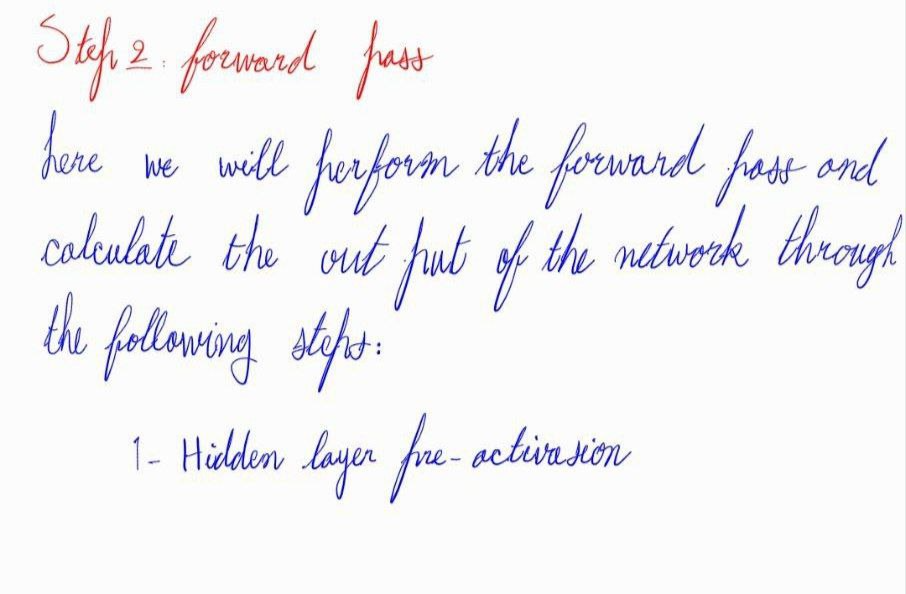

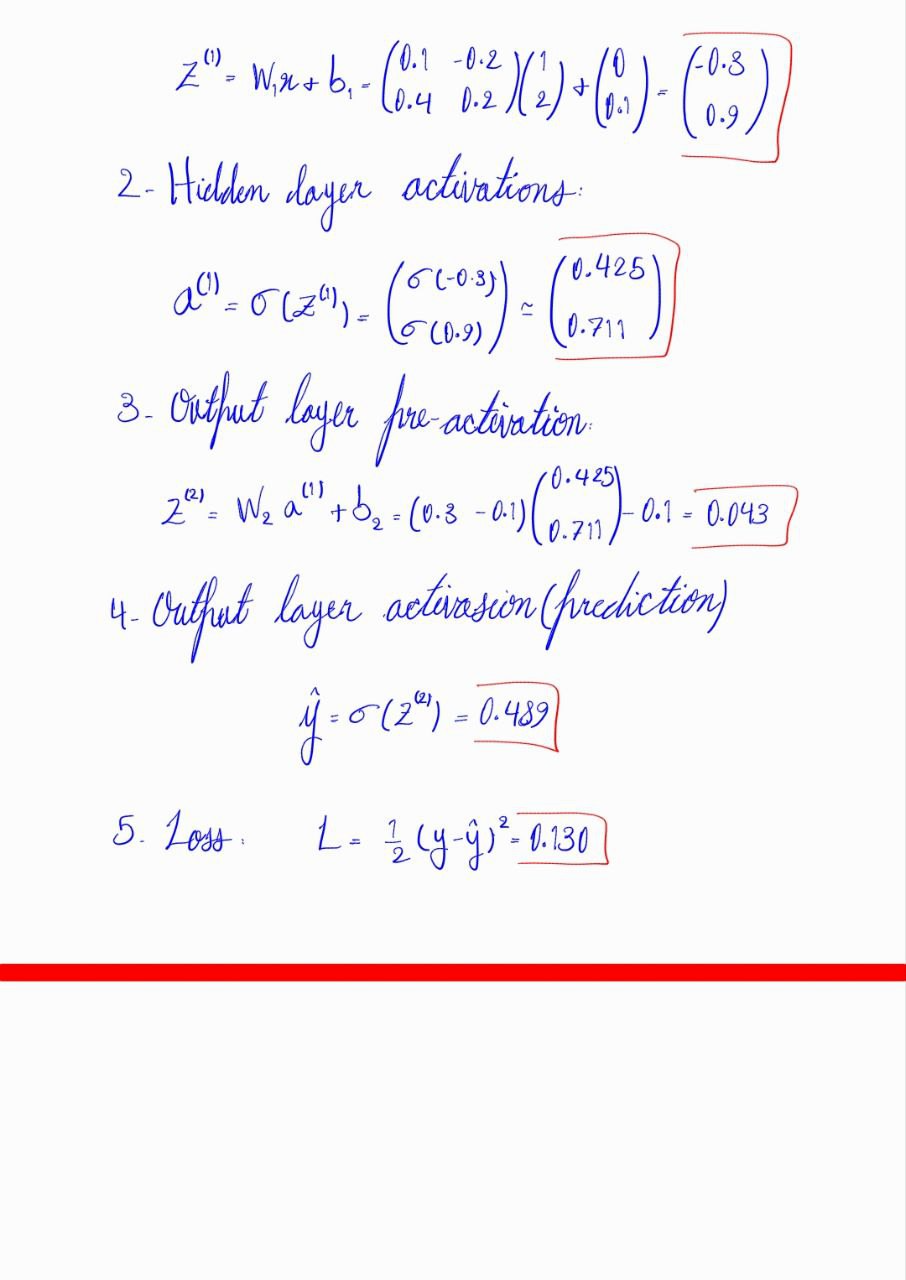

### Step 3: Backpropagation  

3.1 Compute δ² = (ŷ − y) · σ′(z²)  
3.2 Compute gradients:  
- ∂L/∂W2 = δ² · a¹ᵀ  
- ∂L/∂b2 = δ²  
3.3 Compute δ¹ = (W2ᵀ · δ²) * σ′(z¹)  
3.4 Compute gradients:  
- ∂L/∂W1 = δ¹ · xᵀ  
- ∂L/∂b1 = δ¹

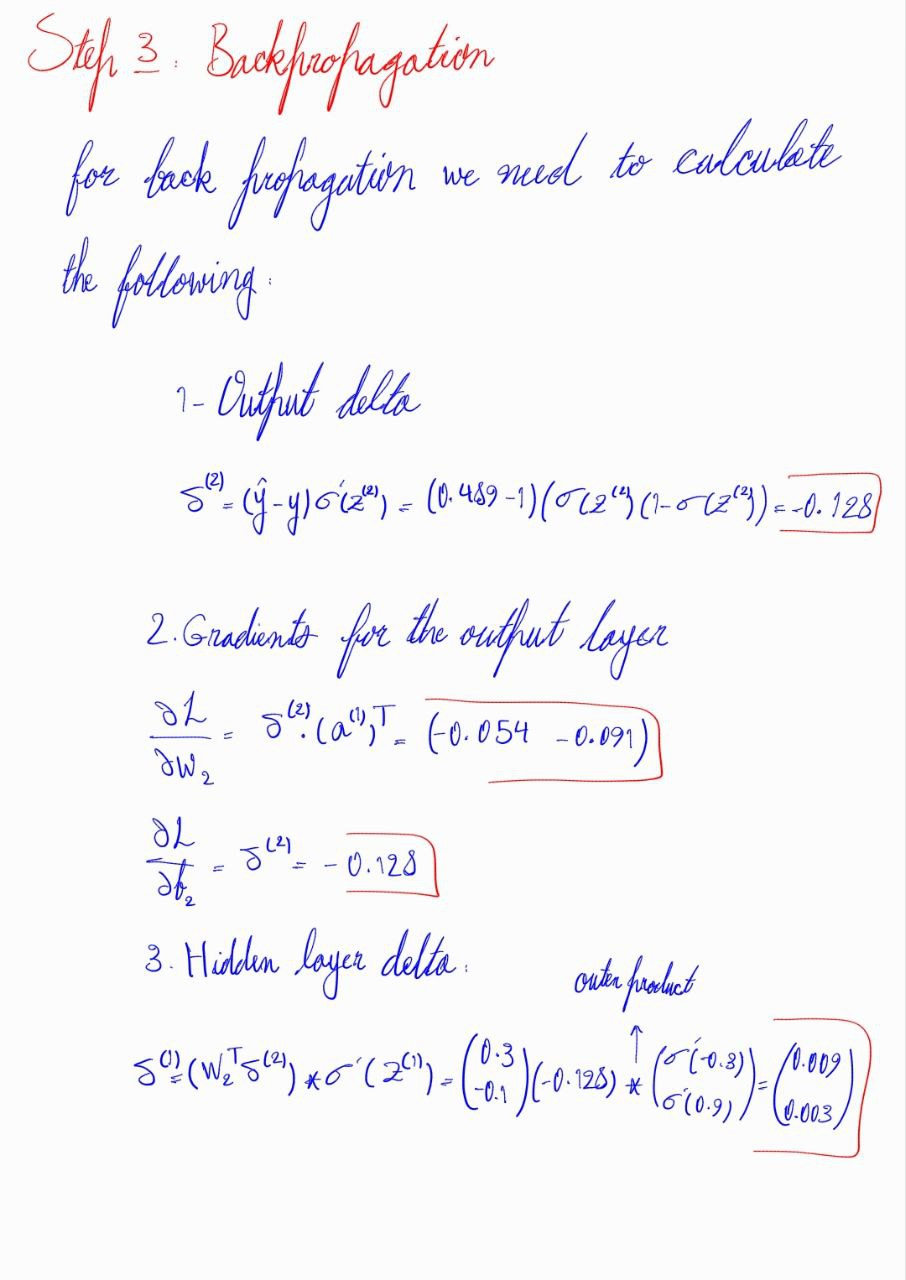

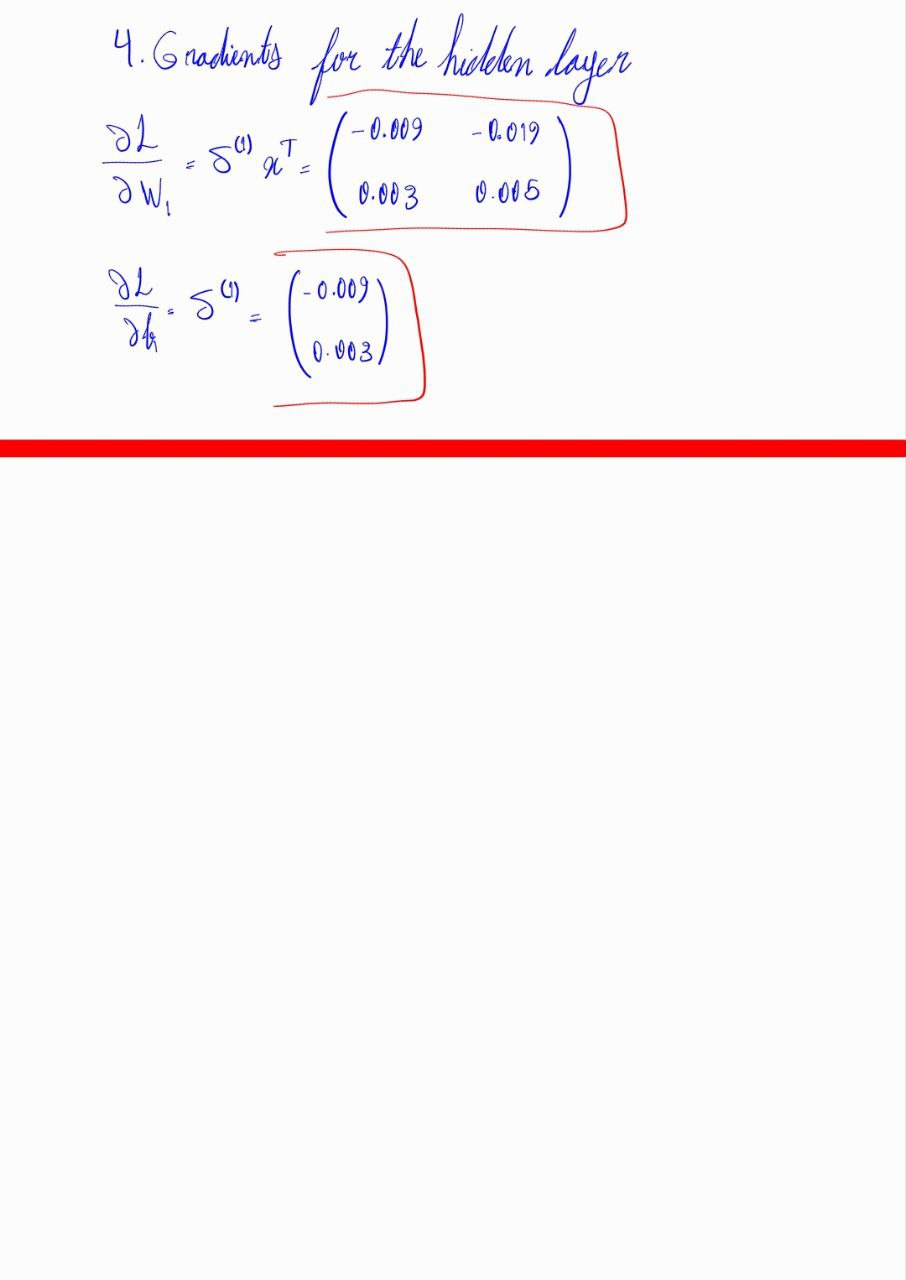

### Step 4: Weight Updates  

Update rules:  
- W2_new = W2 − α · ∂L/∂W2  
- b2_new = b2 − α · ∂L/∂b2  
- W1_new = W1 − α · ∂L/∂W1  
- b1_new = b1 − α · ∂L/∂b1  

Perform these updates and report the new weight matrices and biases.

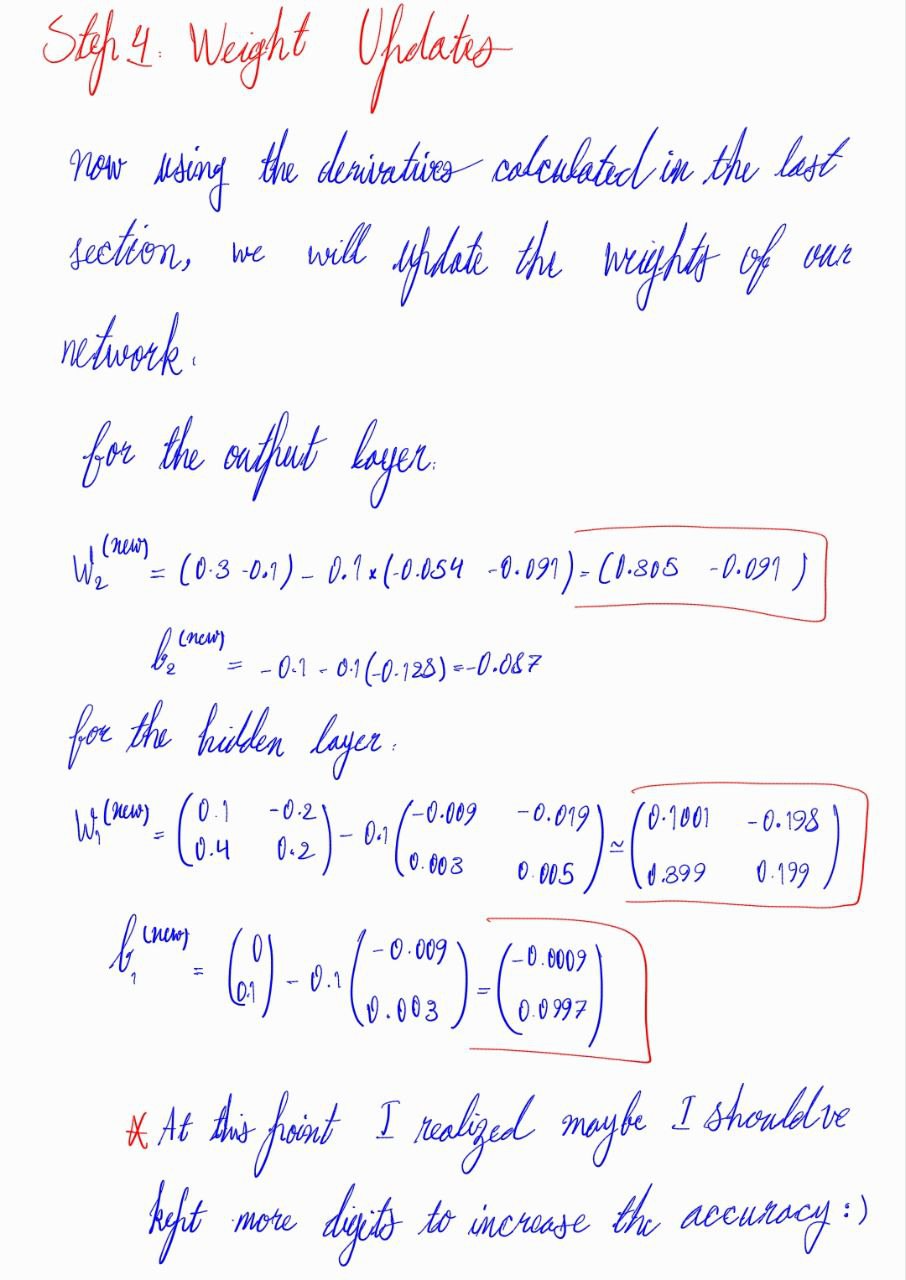

## **Part 2: Python Implementation**


Re-implement the same 2-2-1 network using NumPy. Follow each step closely.

Here we will go over the steps for implementing the network.

### Step 0: Creating the XOR dataset.


Hre we will first make a simple XOR dataset with 4 points. And then make a more complex dataset with many points, we will train and test models on both datasets.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

X = np.array([[0,0,1,1],
              [0,1,0,1]], dtype=float)
Y = np.array([[0,1,1,0]], dtype=float)

print("X shape:", X.shape, "Y shape:", Y.shape)


X shape: (2, 4) Y shape: (1, 4)


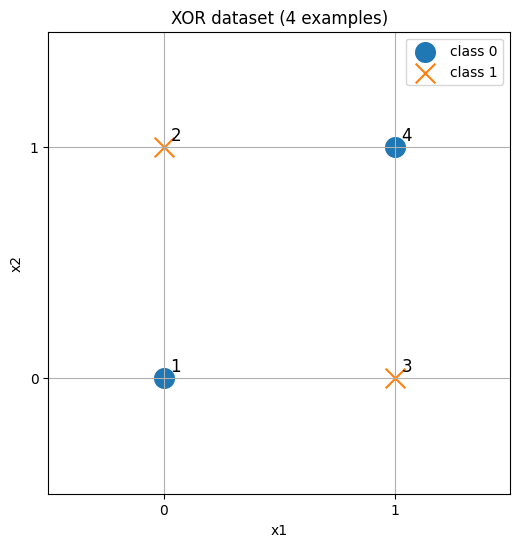

In [ ]:
xs = X[0, :]
ys = X[1, :]
labels = Y.flatten()

idx0 = labels == 0
idx1 = labels == 1

plt.figure(figsize=(6,6))
plt.scatter(xs[idx0], ys[idx0], marker='o', s=200, label='class 0')
plt.scatter(xs[idx1], ys[idx1], marker='x', s=200, label='class 1')

for i, (x, y) in enumerate(zip(xs, ys), start=1):
    plt.annotate(str(i), (x + 0.03, y + 0.03), fontsize=12)

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('XOR dataset (4 examples)')
plt.grid(True)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

Now let's make the more complex dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def make_xor_random(n_samples=2000, jitter=0.25, seed=42):
    rng = np.random.default_rng(seed)
    bits = rng.integers(0, 2, size=(2, n_samples))
    xor_vals = (bits[0, :] ^ bits[1, :]).astype(float)

    noise = rng.normal(scale=jitter, size=bits.shape)
    X_more = (bits + noise).astype(float)
    Y_more = xor_vals.reshape(1, -1)

    perm = rng.permutation(n_samples)
    X_more = X_more[:, perm]
    Y_more = Y_more[:, perm]

    return X_more, Y_more

X_more, Y_more = make_xor_random()
print("X_more shape:", X_more.shape, "Y_more shape:", Y_more.shape)

X_more shape: (2, 2000) Y_more shape: (1, 2000)


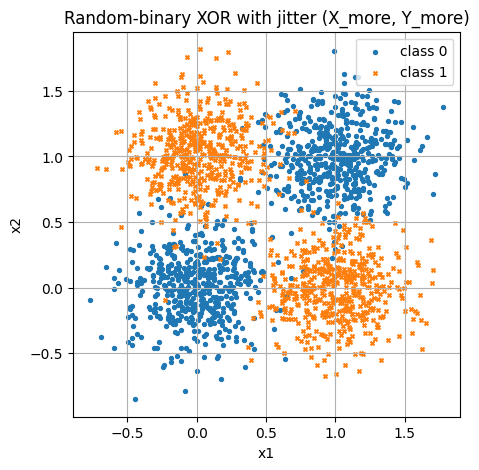

In [ ]:

plt.figure(figsize=(5,5))
labels = Y_more.flatten()
plt.scatter(X_more[0, labels==0], X_more[1, labels==0], marker='o', s=8, label='class 0')
plt.scatter(X_more[0, labels==1], X_more[1, labels==1], marker='x', s=8, label='class 1')
plt.title('Random-binary XOR with jitter (X_more, Y_more)')
plt.xlabel('x1'); plt.ylabel('x2'); plt.legend(); plt.grid(True); plt.show()

### Step 1: Define activation functions and their derivatives

Here we will define the activation functions.

In [ ]:
def sigmoid(z):
    # for numeric stability we will clip z to avoid overflow in exp
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    return np.maximum(0, z)

def relu_prime(z):
    return (z > 0).astype(float)

### Step 2: Initialize parameters

Here we will define a function to initialize the parameter. To take the code given in the question a step further we will implement two methods for initialization.

In [ ]:
def initialize_parameters(n_x, n_h, n_y, init='xavier', seed=None):
    if seed is not None:
        np.random.seed(seed)
    if init == 'small':
        W1 = np.random.randn(n_h, n_x) * 0.01
        W2 = np.random.randn(n_y, n_h) * 0.01
    elif init == 'xavier':
        W1 = np.random.randn(n_h, n_x) * np.sqrt(1.0 / n_x)
        W2 = np.random.randn(n_y, n_h) * np.sqrt(1.0 / n_h)
    else:
        raise ValueError("init must be 'small' or 'xavier'")
    b1 = np.zeros((n_h, 1))
    b2 = np.zeros((n_y, 1))
    return W1, b1, W2, b2

### Step 3: Forward and backward propagation functions

Later on we are going to test both sigmoid and relu for our model, so in this step we will change the given code to accommodate the usage of both activation functions. (another function for predication has also been added)

In [ ]:
def forward_propagation(X, W1, b1, W2, b2, hidden_activation='sigmoid'):
    Z1 = W1.dot(X) + b1
    if hidden_activation == 'sigmoid':
        A1 = sigmoid(Z1)
    elif hidden_activation == 'relu':
        A1 = relu(Z1)
    else:
        raise ValueError("hidden_activation must be 'sigmoid' or 'relu'")
    Z2 = W2.dot(A1) + b2
    A2 = sigmoid(Z2)
    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return A2, cache

def compute_cost(A2, Y):
    m = Y.shape[1]
    cost = 0.5 * np.sum((A2 - Y)**2) / m
    return cost

def predict(X, W1, b1, W2, b2, hidden_activation='sigmoid'):
    A2, _ = forward_propagation(X, W1, b1, W2, b2, hidden_activation=hidden_activation)
    preds = (A2 > 0.5).astype(int)
    return preds

def backward_propagation(X, Y, cache, W2, hidden_activation='sigmoid'):
    m = X.shape[1]
    A1, A2 = cache['A1'], cache['A2']
    Z1, Z2 = cache['Z1'], cache['Z2']

    dZ2 = (A2 - Y) * sigmoid_prime(Z2)
    dW2 = (dZ2.dot(A1.T)) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m


    if hidden_activation == 'sigmoid':
        dZ1 = (W2.T.dot(dZ2)) * sigmoid_prime(Z1)
    elif hidden_activation == 'relu':
        dZ1 = (W2.T.dot(dZ2)) * relu_prime(Z1)
    else:
        raise ValueError("hidden_activation must be 'sigmoid' or 'relu'")

    dW1 = (dZ1.dot(X.T)) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    grads = {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}
    return grads


### Step 4: Training loop

Now let's define the training loop. (the code has been modified to reflate the changes and also allow us to keep the history (for plots later on))

In [ ]:
def train(X, Y, n_h=2, num_iterations=10000, learning_rate=0.1,
          hidden_activation='sigmoid', init='xavier', print_every=1000, seed=0):
    n_x = X.shape[0]
    n_y = Y.shape[0]
    W1, b1, W2, b2 = initialize_parameters(n_x, n_h, n_y, init=init, seed=seed)
    costs = []
    for i in range(num_iterations):
        A2, cache = forward_propagation(X, W1, b1, W2, b2, hidden_activation=hidden_activation)
        cost = compute_cost(A2, Y)
        grads = backward_propagation(X, Y, cache, W2, hidden_activation=hidden_activation)

        W1 -= learning_rate * grads['dW1']
        b1 -= learning_rate * grads['db1']
        W2 -= learning_rate * grads['dW2']
        b2 -= learning_rate * grads['db2']

        costs.append(cost)
        if (i % print_every) == 0:
            print(f"Iter {i:5d} | cost: {cost:.6f}")
    params = {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}
    history = {'costs': costs}
    return params, history

### Step 5: Experiment and Analysis  

In this part we will train the model on both datasets, draw the plots and decision boundary and calculate the accuracy of the model.

First let's define a function to plot the decision boundaries.

In [ ]:
def plot_decision_boundary(params, X_data, Y_data,
                                     hidden_activation='sigmoid',
                                     padding_frac=0.08,
                                     grid_resolution=300,
                                     cmap='RdBu',
                                     title="Decision boundary"):
    W1, b1, W2, b2 = params['W1'], params['b1'], params['W2'], params['b2']

    x_min, x_max = X_data[0, :].min(), X_data[0, :].max()
    y_min, y_max = X_data[1, :].min(), X_data[1, :].max()
    x_range = x_max - x_min if x_max > x_min else 1.0
    y_range = y_max - y_min if y_max > y_min else 1.0
    pad_x = padding_frac * x_range
    pad_y = padding_frac * y_range

    x_min_plot, x_max_plot = x_min - pad_x, x_max + pad_x
    y_min_plot, y_max_plot = y_min - pad_y, y_max + pad_y

    xx = np.linspace(x_min_plot, x_max_plot, grid_resolution)
    yy = np.linspace(y_min_plot, y_max_plot, grid_resolution)
    XX, YY = np.meshgrid(xx, yy)
    grid = np.vstack([XX.ravel(), YY.ravel()])  # shape (2, N)

    A2_grid, _ = forward_propagation(grid, W1, b1, W2, b2, hidden_activation=hidden_activation)
    Z = A2_grid.reshape(XX.shape)

    plt.figure(figsize=(7,6))
    plt.contourf(XX, YY, Z, levels=50, cmap=cmap, alpha=0.9)
    plt.contour(XX, YY, Z, levels=[0.5], colors='k', linewidths=1.0)
    plt.scatter(X_data[0, :], X_data[1, :], c=Y_data.ravel(), cmap=cmap,
                edgecolors='k', linewidths=0.3, s=18, alpha=0.8)
    plt.xlim(x_min_plot, x_max_plot)
    plt.ylim(y_min_plot, y_max_plot)
    plt.xlabel('x1'); plt.ylabel('x2')
    plt.title(title)
    plt.show()

#### 2.5.1. Testing the model on the simple dataset

Here we will train a simple model with two hidden neurons on the first dataset. We will train one model using sigmoid and another using relu.

Training with hidden activation = sigmoid
Iter     0 | cost: 0.127584
Iter  2000 | cost: 0.121090
Iter  4000 | cost: 0.111744
Iter  6000 | cost: 0.099752
Iter  8000 | cost: 0.090064
Iter 10000 | cost: 0.082433
Iter 12000 | cost: 0.076244
Iter 14000 | cost: 0.070853
Iter 16000 | cost: 0.053981
Iter 18000 | cost: 0.026164
Iter 20000 | cost: 0.013765
Iter 22000 | cost: 0.008507
Iter 24000 | cost: 0.005923
Iter 26000 | cost: 0.004458
Iter 28000 | cost: 0.003537
Iter 30000 | cost: 0.002912
Iter 32000 | cost: 0.002465
Iter 34000 | cost: 0.002130
Iter 36000 | cost: 0.001872
Iter 38000 | cost: 0.001666
Iter 40000 | cost: 0.001500
Iter 42000 | cost: 0.001362
Iter 44000 | cost: 0.001246
Iter 46000 | cost: 0.001148
Iter 48000 | cost: 0.001064
Iter 50000 | cost: 0.000990
Iter 52000 | cost: 0.000926
Iter 54000 | cost: 0.000869
Iter 56000 | cost: 0.000819
Iter 58000 | cost: 0.000774
Iter 60000 | cost: 0.000733
Iter 62000 | cost: 0.000696
Iter 64000 | cost: 0.000663
Iter 66000 | cost: 0.000633
Iter 6

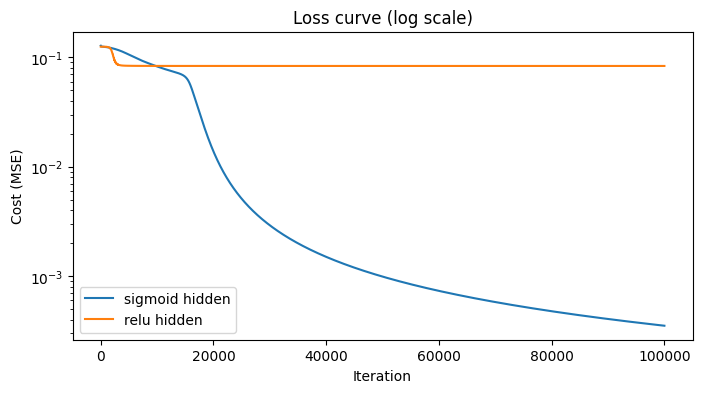

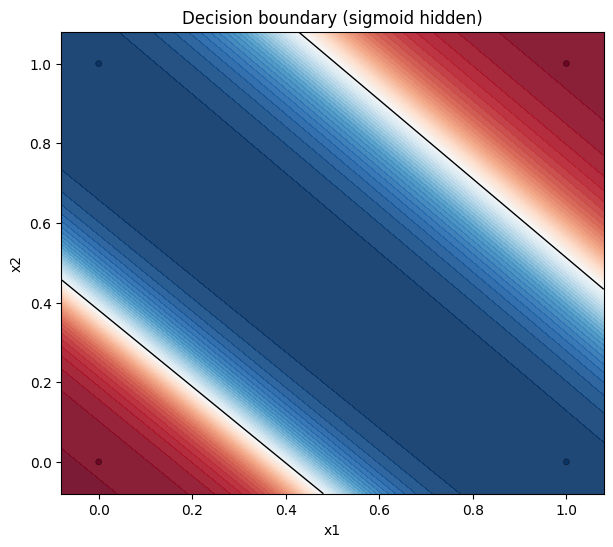

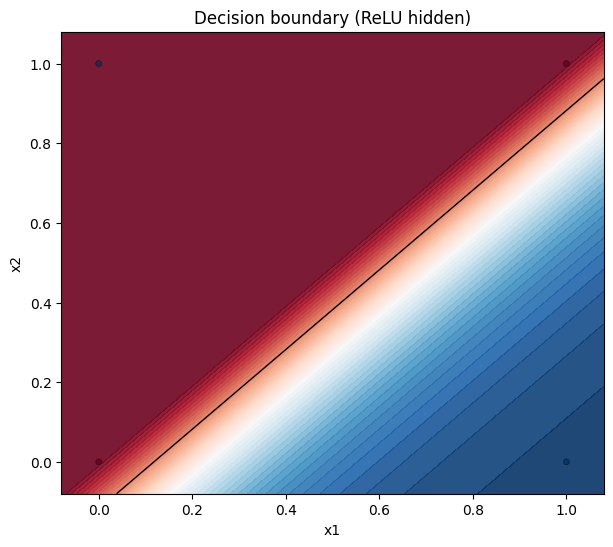

Final accuracy (sigmoid hidden): 100.00%
Final accuracy (ReLU hidden):    75.00%


In [ ]:
n_h = 2
iters = 100000
lr = 0.1

print("Training with hidden activation = sigmoid")
params_sig, hist_sig = train(X, Y, n_h=n_h, num_iterations=iters, learning_rate=lr,
                            hidden_activation='sigmoid', init='xavier', print_every=2000, seed=1)

print("\nTraining with hidden activation = relu")
params_relu, hist_relu = train(X, Y, n_h=n_h, num_iterations=iters, learning_rate=lr,
                              hidden_activation='relu', init='small', print_every=2000, seed=1)

plt.figure(figsize=(8,4))
plt.plot(hist_sig['costs'], label='sigmoid hidden')
plt.plot(hist_relu['costs'], label='relu hidden')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.legend()
plt.title('Loss curve (log scale)')
plt.show()

plot_decision_boundary(params_sig, X, Y, hidden_activation='sigmoid', title='Decision boundary (sigmoid hidden)')
plot_decision_boundary(params_relu, X, Y, hidden_activation='relu', title='Decision boundary (ReLU hidden)',)

pred_sig = predict(X, **params_sig, hidden_activation='sigmoid')
pred_relu = predict(X, **params_relu, hidden_activation='relu')
acc_sig = np.mean(pred_sig == Y)
acc_relu = np.mean(pred_relu == Y)
print(f"Final accuracy (sigmoid hidden): {acc_sig*100:.2f}%")
print(f"Final accuracy (ReLU hidden):    {acc_relu*100:.2f}%")

After some quick hyper parameter tuning, we can see that the model using relu didn't converge and only separated the data with a single line but the model using sigmoid managed to separate the data (although not the way we expected since the data is XOR but it should be fine on the bigger dataset), I couldn't understand why this was the case so I asked chatGPT and got this answer:

**Why ReLU model failed to converge / produced only a single line**

Bad initialization for ReLU (dead / inactive neurons).

Standard Xavier init is tuned for sigmoids/tanh. For ReLU you should use He initialization (scale ≈ √(2 / fan_in)). With wrong scale the pre-activations can be negative for many units, producing zero gradients and effectively “dead” neurons so the network becomes linear (one line).

ReLU dying problem.

If neurons get pushed to negative pre-activation early, gradient is zero there and they never recover — the network can collapse to a simple linear separator.

Loss choice + gradient magnitude.

You used MSE (with sigmoid output). For classification problems binary cross-entropy (BCE) with sigmoid output is numerically and optimization-wise often better. BCE gives larger, more meaningful gradients near correct/wrong boundaries; MSE can produce tiny gradients that make ReLU harder to train.

Learning rate / optimizer / seed sensitivity.

ReLU networks can be more sensitive to learning rate and initialization. Too large LR may push neurons dead; too small LR slows or stalls training. Also plain SGD without momentum/Adam can converge slowly or to bad local optima on tiny networks.

Small network + single restart.

A 2-2-1 net can represent XOR but success depends on initialization and training dynamics. If both hidden units learn similar roles (symmetry) you may effectively lose representational power.

#### 2.5.1. Testing the model on the more complex dataset

Now let's repeat the process for the more complex dataset.

Training with hidden activation = sigmoid
Iter     0 | cost: 0.127010
Iter  2000 | cost: 0.125305
Iter  4000 | cost: 0.125061
Iter  6000 | cost: 0.124827
Iter  8000 | cost: 0.124571
Iter 10000 | cost: 0.124289
Iter 12000 | cost: 0.123979
Iter 14000 | cost: 0.123640
Iter 16000 | cost: 0.123272
Iter 18000 | cost: 0.122876
Iter 20000 | cost: 0.122456
Iter 22000 | cost: 0.122015
Iter 24000 | cost: 0.121555
Iter 26000 | cost: 0.121079
Iter 28000 | cost: 0.120591
Iter 30000 | cost: 0.120092
Iter 32000 | cost: 0.119583
Iter 34000 | cost: 0.119065
Iter 36000 | cost: 0.118539
Iter 38000 | cost: 0.118006
Iter 40000 | cost: 0.117466
Iter 42000 | cost: 0.116920
Iter 44000 | cost: 0.116367
Iter 46000 | cost: 0.115810
Iter 48000 | cost: 0.115248
Iter 50000 | cost: 0.114682
Iter 52000 | cost: 0.114112
Iter 54000 | cost: 0.113539
Iter 56000 | cost: 0.112965
Iter 58000 | cost: 0.112388
Iter 60000 | cost: 0.111810
Iter 62000 | cost: 0.111231
Iter 64000 | cost: 0.110651
Iter 66000 | cost: 0.110071
Iter 6

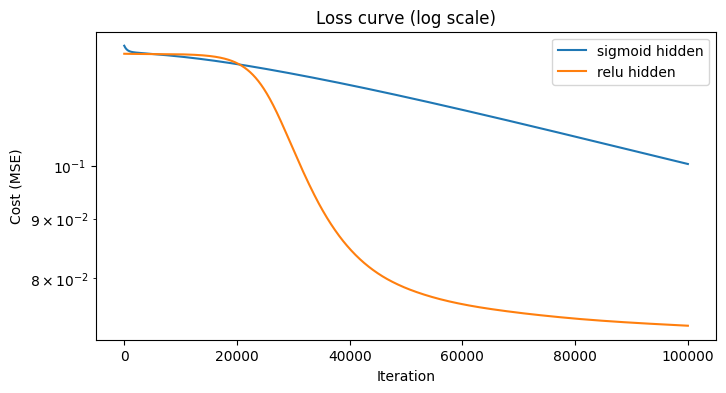

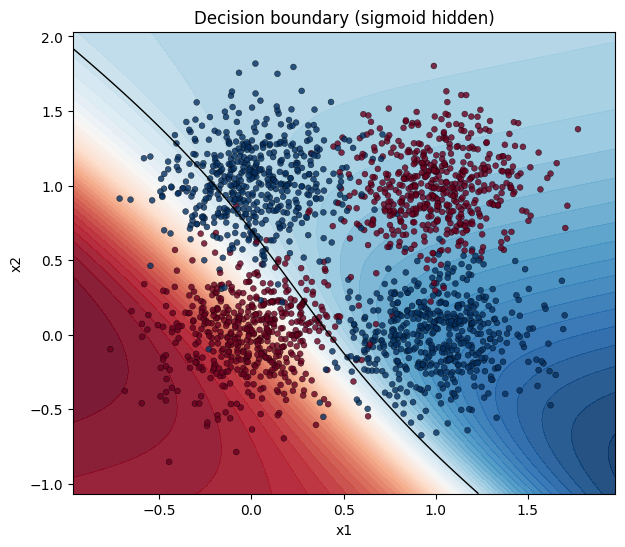

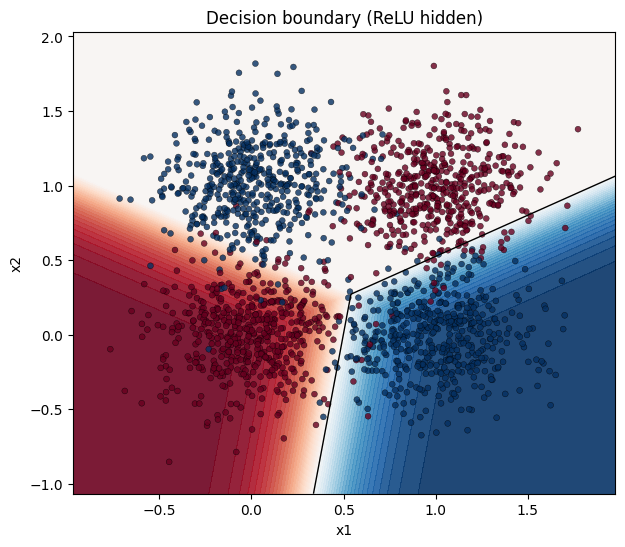

Final accuracy (sigmoid hidden): 66.60%
Final accuracy (ReLU hidden):    73.25%


In [ ]:
n_h = 2
iters = 100000
lr = 0.01

print("Training with hidden activation = sigmoid")
params_sig, hist_sig = train(X_more, Y_more, n_h=n_h, num_iterations=iters, learning_rate=lr,
                            hidden_activation='sigmoid', init='xavier', print_every=2000, seed=1)

print("\nTraining with hidden activation = relu")
params_relu, hist_relu = train(X_more, Y_more, n_h=n_h, num_iterations=iters, learning_rate=lr,
                              hidden_activation='relu', init='small', print_every=2000, seed=1)

plt.figure(figsize=(8,4))
plt.plot(hist_sig['costs'], label='sigmoid hidden')
plt.plot(hist_relu['costs'], label='relu hidden')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.legend()
plt.title('Loss curve (log scale)')
plt.show()

plot_decision_boundary(params_sig, X_more, Y_more, hidden_activation='sigmoid', title='Decision boundary (sigmoid hidden)')
plot_decision_boundary(params_relu, X_more, Y_more, hidden_activation='relu', title='Decision boundary (ReLU hidden)')

pred_sig = predict(X_more, **params_sig, hidden_activation='sigmoid')
pred_relu = predict(X_more, **params_relu, hidden_activation='relu')
acc_sig = np.mean(pred_sig == Y_more)
acc_relu = np.mean(pred_relu == Y_more)
print(f"Final accuracy (sigmoid hidden): {acc_sig*100:.2f}%")
print(f"Final accuracy (ReLU hidden):    {acc_relu*100:.2f}%")

This time both models failed to predict the boundaries correctly (even after parameter tuning) but ReLU managed to perform better this time around.

As our last test we will change the number of hidden neurons to see if adding more complexity helps or not.

Training with hidden activation = sigmoid
Iter     0 | cost: 0.126173
Iter  2000 | cost: 0.125100
Iter  4000 | cost: 0.124883
Iter  6000 | cost: 0.124671
Iter  8000 | cost: 0.124454
Iter 10000 | cost: 0.124231
Iter 12000 | cost: 0.123995
Iter 14000 | cost: 0.123744
Iter 16000 | cost: 0.123472
Iter 18000 | cost: 0.123176
Iter 20000 | cost: 0.122850
Iter 22000 | cost: 0.122491
Iter 24000 | cost: 0.122093
Iter 26000 | cost: 0.121651
Iter 28000 | cost: 0.121161
Iter 30000 | cost: 0.120616
Iter 32000 | cost: 0.120012
Iter 34000 | cost: 0.119343
Iter 36000 | cost: 0.118603
Iter 38000 | cost: 0.117788
Iter 40000 | cost: 0.116891
Iter 42000 | cost: 0.115908
Iter 44000 | cost: 0.114832
Iter 46000 | cost: 0.113658
Iter 48000 | cost: 0.112382
Iter 50000 | cost: 0.110998
Iter 52000 | cost: 0.109502
Iter 54000 | cost: 0.107892
Iter 56000 | cost: 0.106164
Iter 58000 | cost: 0.104319
Iter 60000 | cost: 0.102356
Iter 62000 | cost: 0.100278
Iter 64000 | cost: 0.098090
Iter 66000 | cost: 0.095799
Iter 6

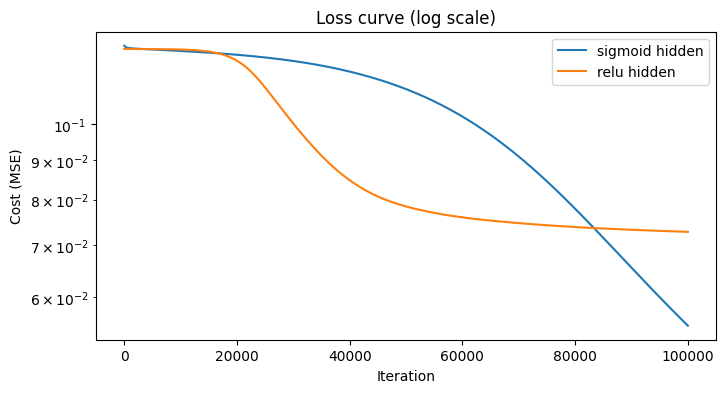

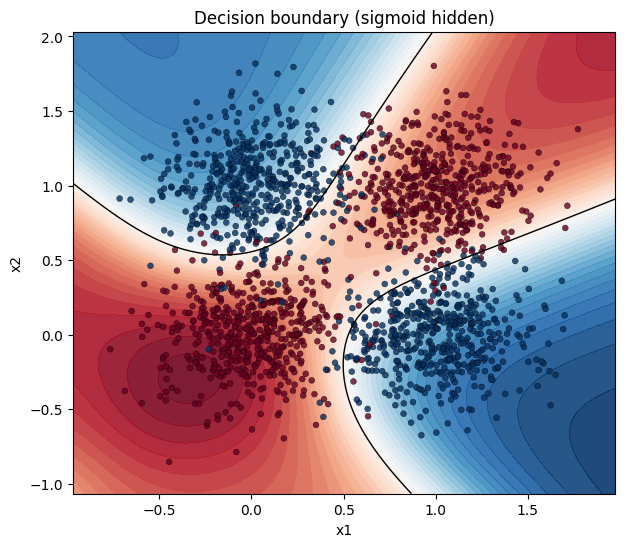

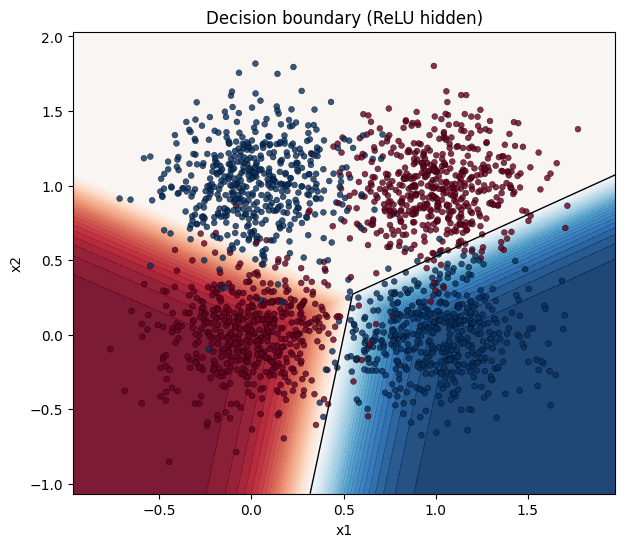

Final accuracy (sigmoid hidden): 94.30%
Final accuracy (ReLU hidden):    73.25%


In [ ]:
n_h = 5
iters = 100000
lr = 0.1

print("Training with hidden activation = sigmoid")
params_sig, hist_sig = train(X_more, Y_more, n_h=n_h, num_iterations=iters, learning_rate=lr,
                            hidden_activation='sigmoid', init='xavier', print_every=2000, seed=1)

print("\nTraining with hidden activation = relu")
params_relu, hist_relu = train(X_more, Y_more, n_h=n_h, num_iterations=iters, learning_rate=lr,
                              hidden_activation='relu', init='small', print_every=2000, seed=1)

plt.figure(figsize=(8,4))
plt.plot(hist_sig['costs'], label='sigmoid hidden')
plt.plot(hist_relu['costs'], label='relu hidden')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.legend()
plt.title('Loss curve (log scale)')
plt.show()

plot_decision_boundary(params_sig, X_more, Y_more, hidden_activation='sigmoid', title='Decision boundary (sigmoid hidden)')
plot_decision_boundary(params_relu, X_more, Y_more, hidden_activation='relu', title='Decision boundary (ReLU hidden)')

pred_sig = predict(X_more, **params_sig, hidden_activation='sigmoid')
pred_relu = predict(X_more, **params_relu, hidden_activation='relu')
acc_sig = np.mean(pred_sig == Y_more)
acc_relu = np.mean(pred_relu == Y_more)
print(f"Final accuracy (sigmoid hidden): {acc_sig*100:.2f}%")
print(f"Final accuracy (ReLU hidden):    {acc_relu*100:.2f}%")

This time we see a massive improvement on the network that uses Sigmoid (by getting a near perfect score of 94%) while the ReLU model didn't improve much.